# Data load and information

In [1]:
#Install necessary packages first:
!pip install torch torchvision torchaudio transformers accelerate bitsandbytes huggingface_hub scikit-learn pandas numpy matplotlib --quiet

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.3 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load your dataset
import pandas as pd

# Replace with your actual file path in Google Drive
df = pd.read_csv('/content/drive/MyDrive/Group Assignment Group6/final_preprocessed.csv')

# Check if loaded correctly
print(df.head())
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Age  Education  EmploymentLengthYears  MonthlyIncome  Dependents  \
0   59        1.0                     11    9067.159786           2   
1   51        0.0                     24    5068.058742           1   
2   24        3.0                      0    2557.541824           0   
3   25        3.0                      0    7535.097299           0   
4   25        4.0                      5    4798.465251           2   

   CreditScore  ExistingLoans  MonthlyDebt  YearsWithBank  HasSavingsAccount  \
0          770              3  1583.065500              7                  1   
1          698              3  1332.052087              7                  1   
2          480              1   911.536097              2                  1   
3          774              1   514.141526              6                  1   
4          590              4  2386.488285  

In [3]:
# Check data
print(df.info())  # Check data types
print(df.isnull().sum())  # Check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Age                                  1000 non-null   int64  
 1   Education                            1000 non-null   float64
 2   EmploymentLengthYears                1000 non-null   int64  
 3   MonthlyIncome                        1000 non-null   float64
 4   Dependents                           1000 non-null   int64  
 5   CreditScore                          1000 non-null   int64  
 6   ExistingLoans                        1000 non-null   int64  
 7   MonthlyDebt                          1000 non-null   float64
 8   YearsWithBank                        1000 non-null   int64  
 9   HasSavingsAccount                    1000 non-null   int64  
 10  HasCheckingAccount                   1000 non-null   int64  
 11  LoanAmount                     

In [4]:
# Check the distribution of the target variable
default_counts = df['LoanDefault'].value_counts()
default_percentages = df['LoanDefault'].value_counts(normalize=True) * 100

print("LoanDefault Value Counts:")
print(default_counts)
print("\nLoanDefault Value Percentages:")
print(default_percentages)

LoanDefault Value Counts:
LoanDefault
0    500
1    500
Name: count, dtype: int64

LoanDefault Value Percentages:
LoanDefault
0    50.0
1    50.0
Name: proportion, dtype: float64


This indicates that 50% of the data has value of 1 for LoanDefault and 0 for the remaining.

# Decision Tree Model Training

## Decision Tree Model 1: Unrestricted Tree (Overfitting Demonstration)

In this experiment, a Decision Tree is trained **without any constraints** on depth or leaf size.
This setup is intentionally used to demonstrate how Decision Trees tend to overfit the training data.


In [6]:
# Separate features (X) and target (y)
X = df.drop(['LoanDefault', 'LoanPurposeDescription'], axis=1)
y = df['LoanDefault']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [7]:
# Unrestricted Decision Tree
dt_overfit = DecisionTreeClassifier(random_state=42)
dt_overfit.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [13]:
# Predictions for unrestricted Decision Tree
y_pred_overfit = dt_overfit.predict(X_test)


In [8]:
# Training vs Test accuracy
train_acc_overfit = dt_overfit.score(X_train, y_train)
test_acc_overfit = dt_overfit.score(X_test, y_test)

print("Unrestricted Decision Tree Performance:")
print(f"Training Accuracy: {train_acc_overfit:.4f}")
print(f"Test Accuracy: {test_acc_overfit:.4f}")


Unrestricted Decision Tree Performance:
Training Accuracy: 1.0000
Test Accuracy: 0.6250


In [9]:
print(f"Tree Depth: {dt_overfit.get_depth()}")
print(f"Number of Leaves: {dt_overfit.get_n_leaves()}")


Tree Depth: 14
Number of Leaves: 128


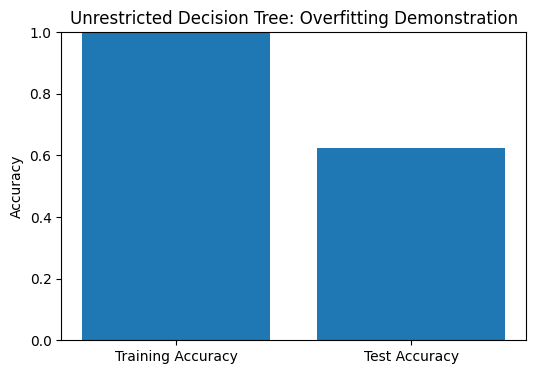

In [10]:
accuracies = [train_acc_overfit, test_acc_overfit]
labels = ['Training Accuracy', 'Test Accuracy']

plt.figure(figsize=(6, 4))
plt.bar(labels, accuracies)
plt.ylim(0, 1)
plt.title('Unrestricted Decision Tree: Overfitting Demonstration')
plt.ylabel('Accuracy')
plt.show()


### Bar Chart Interpretation

* The model performs perfectly on training data, meaning it has learned the training samples extremely well.

* However, performance drops significantly on unseen test data.

* The large gap between training and test accuracy is a classic symptom of overfitting.

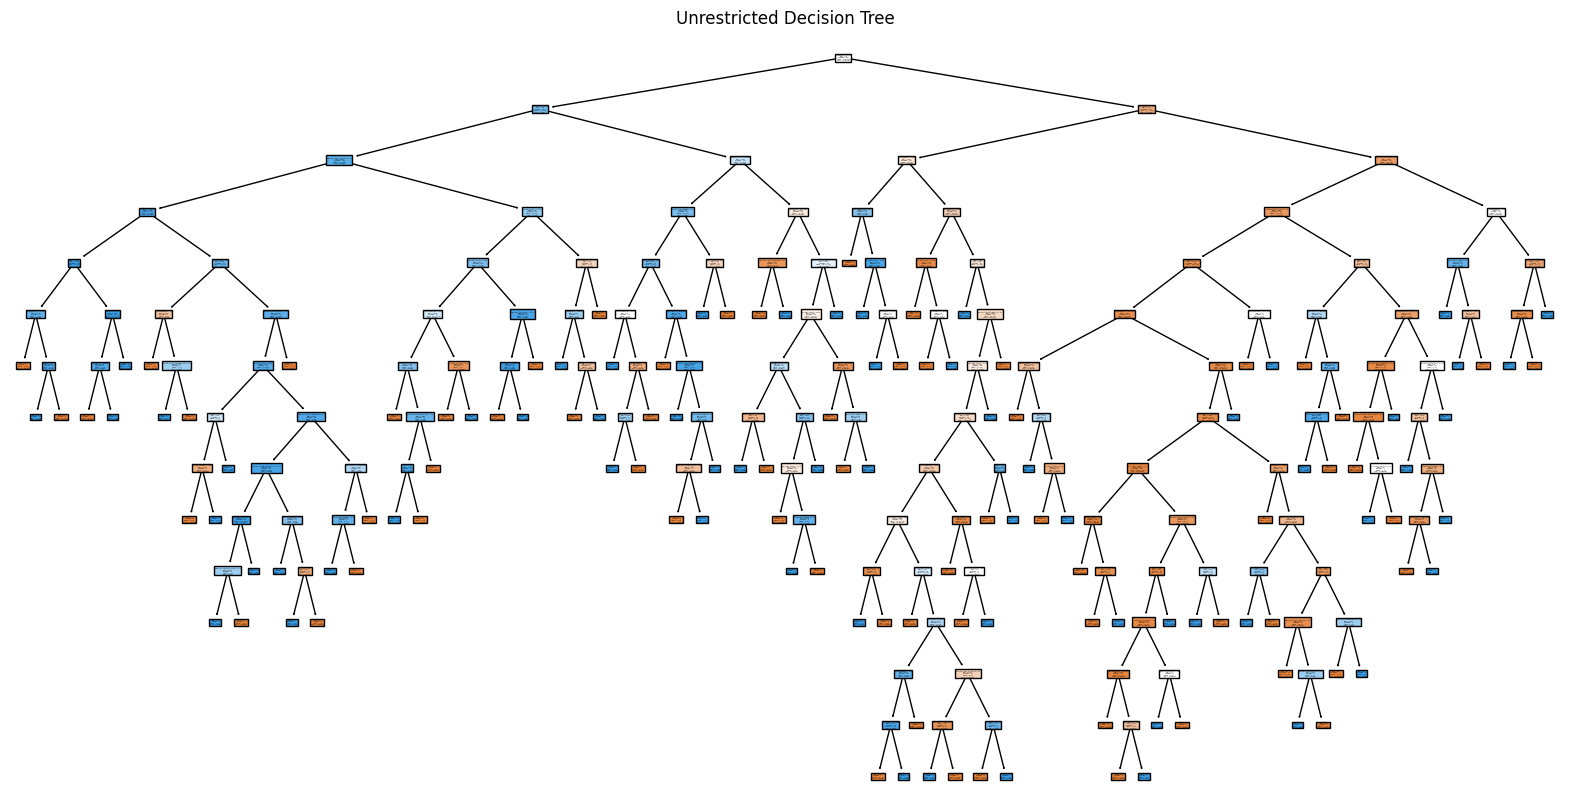

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_overfit,
    feature_names=X.columns,
    class_names=['No Default', 'Default'],
    filled=True,
    max_depth=20
)
plt.title("Unrestricted Decision Tree")
plt.show()


### Unrestricted Decision Tree Interpretation

The decision tree structure reveals a high level of model complexity, as even the top levels of the tree involve splits across multiple features such as credit score, monthly debt, interest rate, loan amount, employment type, and sentiment score. This indicates a highly complex decision boundary. Additionally, many of the splits are based on very specific numerical thresholds (for example, MonthlyDebt ≤ 1753.595), suggesting that the model is learning highly detailed rules tailored to the training data rather than capturing broader, generalizable patterns. Because the tree relies heavily on exact feature values, small variations in the input data could result in substantially different splits, making the model sensitive to noise. This combination of complexity, specificity, and sensitivity explains why the unrestricted Decision Tree is unstable and prone to overfitting.

The **large tree depth and number of leaves suggest that the model has memorized training patterns instead of learning generalizable rules.**


### Evaluation of Unrestricted Tree

In [14]:
# Feature summary
print("Features used:", X.columns.tolist())
print(f"\nNumber of features: {X.shape[1]}")

# Dataset split info
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Model evaluation
print("\n" + "="*50)
print("DECISION TREE MODEL 1 (UNRESTRICTED) - EVALUATION")
print("="*50)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred_overfit):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_overfit, target_names=['No Default', 'Default']))

print("\nConfusion Matrix:")
cm_overfit = confusion_matrix(y_test, y_pred_overfit)
print(cm_overfit)
print(f"\nTrue Negatives: {cm_overfit[0,0]}, False Positives: {cm_overfit[0,1]}")
print(f"False Negatives: {cm_overfit[1,0]}, True Positives: {cm_overfit[1,1]}")


# Display Decision Tree Rules
print("\n" + "="*50)
print("DECISION TREE RULES")
print("="*50)
rules_overfit = export_text(dt_overfit, feature_names=list(X.columns))
print(rules_overfit)

Features used: ['Age', 'Education', 'EmploymentLengthYears', 'MonthlyIncome', 'Dependents', 'CreditScore', 'ExistingLoans', 'MonthlyDebt', 'YearsWithBank', 'HasSavingsAccount', 'HasCheckingAccount', 'LoanAmount', 'LoanTermMonths', 'InterestRate', 'Sentiment_Score', 'EmploymentType_Full-Time', 'EmploymentType_Part-Time', 'EmploymentType_Self-Employed', 'EmploymentType_Unemployed', 'EmploymentSector_Education', 'EmploymentSector_Finance', 'EmploymentSector_Government', 'EmploymentSector_Healthcare', 'EmploymentSector_Manufacturing', 'EmploymentSector_Other', 'EmploymentSector_Retail', 'EmploymentSector_Services', 'EmploymentSector_Technology', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'PropertyOwnership_Own Outright', 'PropertyOwnership_Own with Mortgage', 'PropertyOwnership_Rent', 'LoanPurpose_Car Loan', 'LoanPurpose_Debt Consolidation', 'LoanPurpose_Education', 'LoanPurpose_Home Improvement', 'LoanPurpose_Home Purchase', 'LoanPurpose_Medical', 'LoanPurpo

### Model Evaluation Interpretation (Unrestricted Decision Tree)
The unrestricted Decision Tree achieved an overall test accuracy of 62.5%, with balanced precision and recall across both classes. For the Default class, the model attained a recall of 0.69, indicating a relatively strong ability to correctly identify borrowers who defaulted. However, this came at the cost of a higher false positive rate, as reflected by 44 false positives, where non-defaulting customers were incorrectly classified as defaulters. Similarly, 31 false negatives indicate instances where actual defaulters were misclassified as non-defaulters, highlighting limitations in predictive reliability.

Despite this moderate test performance, the unrestricted nature of the model allows it to learn highly specific decision rules from the training data, contributing to its tendency to overfit. This behavior is consistent with the observed gap between training and test performance, as well as the complex tree structure with numerous splits. Overall, these results demonstrate that while an unrestricted Decision Tree can capture intricate patterns in the training data, it struggles to generalize effectively, reinforcing its susceptibility to overfitting and motivating the need for regularization or ensemble-based approaches such as Random Forest.

## Decision Tree Model 2: Regularized Tree (Reduced Overfitting)

In this experiment, a Decision Tree is trained with constraints on depth and minimum samples per node.
These restrictions are applied to reduce model complexity and mitigate overfitting observed in the unrestricted tree.


In [34]:
# Separate features (X) and target (y)
X = df.drop(['LoanDefault', 'LoanPurposeDescription'], axis=1)  # Drop target and text column
y = df['LoanDefault']

print("Features used:", X.columns.tolist())
print(f"\nNumber of features: {X.shape[1]}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Ensures balanced split
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    min_samples_split=20,
    min_samples_leaf=10
)

dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)


Features used: ['Age', 'Education', 'EmploymentLengthYears', 'MonthlyIncome', 'Dependents', 'CreditScore', 'ExistingLoans', 'MonthlyDebt', 'YearsWithBank', 'HasSavingsAccount', 'HasCheckingAccount', 'LoanAmount', 'LoanTermMonths', 'InterestRate', 'Sentiment_Score', 'EmploymentType_Full-Time', 'EmploymentType_Part-Time', 'EmploymentType_Self-Employed', 'EmploymentType_Unemployed', 'EmploymentSector_Education', 'EmploymentSector_Finance', 'EmploymentSector_Government', 'EmploymentSector_Healthcare', 'EmploymentSector_Manufacturing', 'EmploymentSector_Other', 'EmploymentSector_Retail', 'EmploymentSector_Services', 'EmploymentSector_Technology', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'PropertyOwnership_Own Outright', 'PropertyOwnership_Own with Mortgage', 'PropertyOwnership_Rent', 'LoanPurpose_Car Loan', 'LoanPurpose_Debt Consolidation', 'LoanPurpose_Education', 'LoanPurpose_Home Improvement', 'LoanPurpose_Home Purchase', 'LoanPurpose_Medical', 'LoanPurpo

In [35]:
# Training vs Test accuracy for regularized tree
train_acc_reg = dt_model.score(X_train, y_train)
test_acc_reg = dt_model.score(X_test, y_test)

print("Regularized Decision Tree Performance:")
print(f"Training Accuracy: {train_acc_reg:.4f}")
print(f"Test Accuracy: {test_acc_reg:.4f}")


Regularized Decision Tree Performance:
Training Accuracy: 0.8163
Test Accuracy: 0.6750


In [36]:
print(f"Tree Depth: {dt_model.get_depth()}")
print(f"Number of Leaves: {dt_model.get_n_leaves()}")


Tree Depth: 5
Number of Leaves: 23


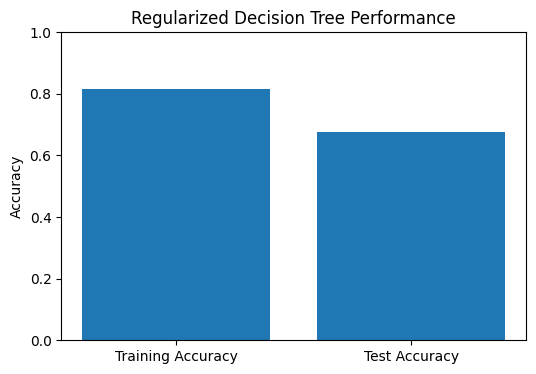

In [17]:
labels = ['Training Accuracy', 'Test Accuracy']
accuracies_reg = [train_acc_reg, test_acc_reg]

plt.figure(figsize=(6, 4))
plt.bar(labels, accuracies_reg)
plt.ylim(0, 1)
plt.title('Regularized Decision Tree Performance')
plt.ylabel('Accuracy')
plt.show()


### Bar Chart Interpretation (Regularized Decision Tree)

After applying constraints on tree depth and minimum samples per node, the Decision Tree exhibits a smaller
gap between training and test accuracy. This indicates improved generalization and reduced overfitting.
However, the constrained model sacrifices some training performance, illustrating the trade-off between
model complexity and generalization.


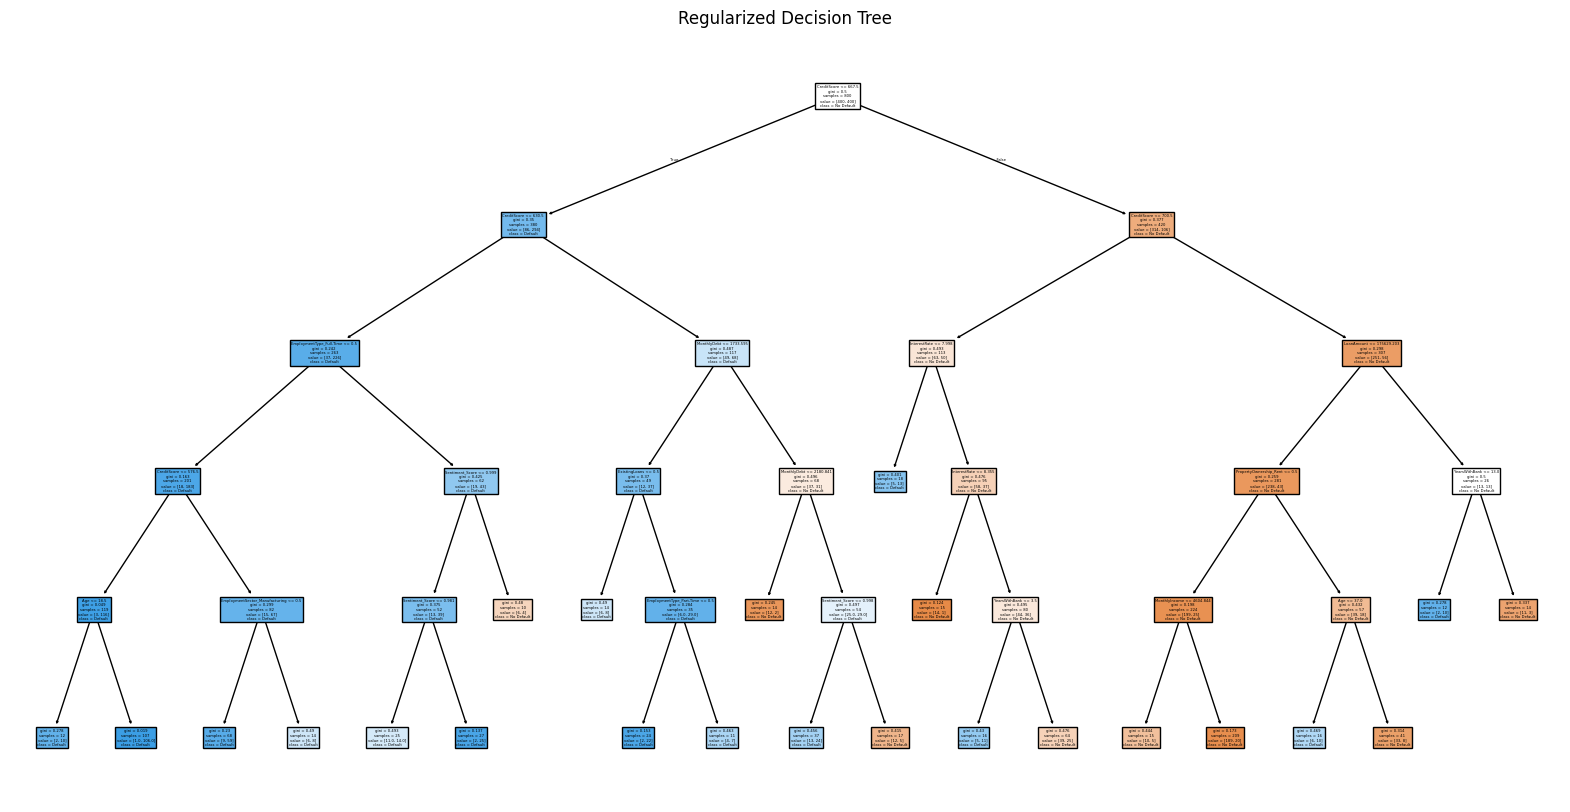

In [37]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Default', 'Default'],
    filled=True,
    max_depth=20
)
plt.title("Regularized Decision Tree")
plt.show()


### Regularized Decision Tree Interpretation
The visualization of the regularized Decision Tree illustrates how constraining model complexity improves generalization. By limiting the maximum tree depth and enforcing minimum sample requirements at each split, the tree forms broader and more stable decision rules instead of excessively fine-grained splits. Compared to the unrestricted tree, the regularized model contains fewer levels and leaf nodes, with each split supported by a larger number of samples. This reduces sensitivity to noise and prevents the model from memorizing specific training instances. While the regularized structure may sacrifice some training accuracy, it produces more interpretable and robust decision boundaries, leading to improved performance on unseen test data.

### Evaluation of Regularized Tree

In [38]:
# Feature summary
print("Features used:", X.columns.tolist())
print(f"\nNumber of features: {X.shape[1]}")

# Dataset split info
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Model evaluation
print("\n" + "="*50)
print("DECISION TREE MODEL 2 (REGULARIZED) - EVALUATION")
print("="*50)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

print("\nConfusion Matrix:")
cm_reg = confusion_matrix(y_test, y_pred)
print(cm_reg)
print(f"\nTrue Negatives: {cm_reg[0,0]}, False Positives: {cm_reg[0,1]}")
print(f"False Negatives: {cm_reg[1,0]}, True Positives: {cm_reg[1,1]}")

# Display Decision Tree Rules (Regularized Tree)
print("\n" + "="*50)
print("DECISION TREE RULES (REGULARIZED)")
print("="*50)

rules_reg = export_text(dt_model, feature_names=list(X.columns), max_depth=3)
print(rules_reg)


Features used: ['Age', 'Education', 'EmploymentLengthYears', 'MonthlyIncome', 'Dependents', 'CreditScore', 'ExistingLoans', 'MonthlyDebt', 'YearsWithBank', 'HasSavingsAccount', 'HasCheckingAccount', 'LoanAmount', 'LoanTermMonths', 'InterestRate', 'Sentiment_Score', 'EmploymentType_Full-Time', 'EmploymentType_Part-Time', 'EmploymentType_Self-Employed', 'EmploymentType_Unemployed', 'EmploymentSector_Education', 'EmploymentSector_Finance', 'EmploymentSector_Government', 'EmploymentSector_Healthcare', 'EmploymentSector_Manufacturing', 'EmploymentSector_Other', 'EmploymentSector_Retail', 'EmploymentSector_Services', 'EmploymentSector_Technology', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'PropertyOwnership_Own Outright', 'PropertyOwnership_Own with Mortgage', 'PropertyOwnership_Rent', 'LoanPurpose_Car Loan', 'LoanPurpose_Debt Consolidation', 'LoanPurpose_Education', 'LoanPurpose_Home Improvement', 'LoanPurpose_Home Purchase', 'LoanPurpose_Medical', 'LoanPurpo

### Comparison Between Unrestricted and Regularized Decision Trees

Compared to the unrestricted Decision Tree, the regularized model demonstrates clear improvements in generalization performance. The test accuracy increases from 62.5% to 67.5%, indicating that constraining tree complexity allows the model to better capture underlying patterns rather than memorizing training data. This improvement is further supported by the classification metrics, where the regularized tree achieves a higher F1-score for the Default class (0.70 compared to 0.65 in the unrestricted model), reflecting a better balance between precision and recall for identifying high-risk borrowers.

Analysis of the confusion matrix also reveals meaningful improvements. The number of true positives increases from 69 to 77, while false negatives decrease from 31 to 23, indicating that the regularized tree is more effective at correctly identifying loan defaulters. Although false positives remain relatively high, this trade-off is acceptable in credit risk contexts where correctly detecting potential defaulters is often prioritized over misclassifying low-risk customers. Overall, the reduced performance gap between training and test data, combined with improved predictive stability, confirms that regularization successfully mitigates overfitting while enhancing model reliability. These results highlight the bias–variance trade-off inherent in Decision Trees and motivate the use of ensemble methods such as Random Forest to further improve generalization.

In [25]:
# Extract classification reports as dictionaries
report_overfit = classification_report(
    y_test, y_pred_overfit, output_dict=True
)
report_reg = classification_report(
    y_test, y_pred, output_dict=True
)

comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree (Unrestricted)",
        "Decision Tree (Regularized)"
    ],
    "Test Accuracy": [
        test_acc_overfit,
        test_acc_reg
    ],
    "Default Recall": [
        report_overfit["1"]["recall"],
        report_reg["1"]["recall"]
    ],
    "False Negatives": [
        cm_overfit[1, 0],
        cm_reg[1, 0]
    ],
    "True Positives": [
        cm_overfit[1, 1],
        cm_reg[1, 1]
    ],
    "Overfitting Behavior": [
        "Severe",
        "Reduced"
    ]
})

comparison_df

,Model,Test Accuracy,Default Recall,False Negatives,True Positives,Overfitting Behavior
0,Decision Tree (Unrestricted),0.625,0.69,31,69,Severe
1,Decision Tree (Regularized),0.675,0.77,23,77,Reduced


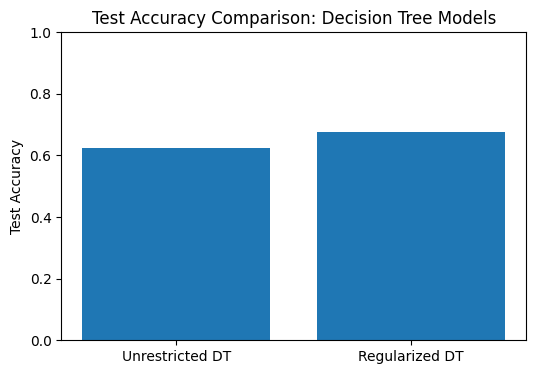

In [26]:
models = ["Unrestricted DT", "Regularized DT"]
test_accuracies = [test_acc_overfit, test_acc_reg]

plt.figure(figsize=(6, 4))
plt.bar(models, test_accuracies)
plt.ylim(0, 1)
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison: Decision Tree Models")
plt.show()


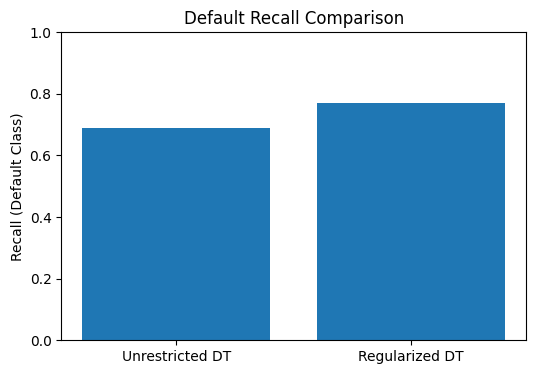

In [27]:
default_recalls = [
    comparison_df.loc[0, "Default Recall"],
    comparison_df.loc[1, "Default Recall"]
]

plt.figure(figsize=(6, 4))
plt.bar(models, default_recalls)
plt.ylim(0, 1)
plt.ylabel("Recall (Default Class)")
plt.title("Default Recall Comparison")
plt.show()


A direct comparison between the unrestricted and regularized Decision Tree models highlights the impact of complexity control on generalization performance. The regularized model achieves higher test accuracy and substantially improves recall for the Default class, indicating a stronger ability to identify high-risk borrowers. This improvement is further reflected in the reduction of false negatives, which decreases from the unrestricted to the regularized model. While the unrestricted Decision Tree benefits from high flexibility, it exhibits severe overfitting due to excessive variance. In contrast, the regularized Decision Tree applies structural constraints that reduce variance, leading to more stable and reliable predictions. These results illustrate the bias–variance trade-off inherent in Decision Trees and justify the transition toward ensemble-based approaches such as Random Forest for further performance gains.

# AI-Assisted Business Interpretation

In this section, feature importance from the regularized Decision Tree model is used as input to a Large Language Model (LLM) to generate high-level business insights. This demonstrates how AI can support strategic decision-making by translating model outputs into actionable recommendations.


In [46]:
import os
import torch
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline

# AUTHENTICATION
os.environ["HUGGINGFACE_TOKEN"] = "HF_TOKEN"
login(token=os.environ["HUGGINGFACE_TOKEN"])

# LOAD QUANTIZED MISTRAL-7B
model_name = "mistralai/Mistral-7B-Instruct-v0.1"

quant_config = BitsAndBytesConfig(load_in_4bit=True)
tokenizer = AutoTokenizer.from_pretrained(model_name, token=os.environ["HUGGINGFACE_TOKEN"])

llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto",
    token=os.environ["HUGGINGFACE_TOKEN"]
)

# Create pipeline (IMPORTANT)
llm_pipeline = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=tokenizer
)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Device set to use cuda:0


In [47]:
# ==============================
# LLM-SUPPORTED MODEL INTERPRETATION
# ==============================

# Export ACTUAL Decision Tree rules
tree_rules = export_text(
    dt_model,
    feature_names=list(X.columns),
    max_depth=3  # keep readable
)

# Use REAL evaluation metrics
train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)

report_dict = classification_report(y_test, y_pred, output_dict=True)

precision_default = report_dict["1"]["precision"]
recall_default = report_dict["1"]["recall"]

real_eval_report = f"""
Test Accuracy: {test_acc:.4f}
Training Accuracy: {train_acc:.4f}
Default Class Precision: {precision_default:.4f}
Default Class Recall: {recall_default:.4f}
Training–Test Accuracy Gap: {(train_acc - test_acc):.4f}
"""

# LLM prompt
prompt = f"""<s>[INST] You are a Financial Risk Analyst.
Review the following Decision Tree rules and evaluation results for a loan default prediction model.

Provide:
1. Two business insights based on the trade-off between high Recall and lower Precision.
2. A non-technical explanation of why the model performs much better on training data than test data.
3. How CreditScore, as the most influential feature, shapes the decision rules and risk assessment.

Decision Tree Rules:
{tree_rules}

Evaluation Results:
{real_eval_report}
[/INST]"""

# Generate insights
output = llm_pipeline(
    prompt,
    max_new_tokens=450,
    do_sample=True,
    temperature=0.7
)

print("\n--- LLM-Supported Model Interpretation ---")
print(output[0]["generated_text"].split("[/INST]")[-1].strip())


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



--- LLM-Supported Model Interpretation ---
1. Business Insights:
a) One insight is that the model has a high recall rate but low precision. This means that the model is identifying many true positives (loan defaults) but also has a high number of false positives (loans that are not defaults). This suggests that the model may be too sensitive to certain features and may need to be fine-tuned to reduce the number of false positives.
b) A second insight is that the model performs much better on training data than test data. This could be due to a number of factors, such as overfitting to the training data, a lack of diversity in the training data, or a difference in the distribution of features between the training and test data sets. To improve the performance of the model on test data, it may be necessary to collect a more diverse and representative data set for training.

2. Non-Technical Explanation:
The model performs better on training data than test data because the training data 

In [48]:
# Feature Importance
print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))



TOP 10 MOST IMPORTANT FEATURES
                           Feature  Importance
5                      CreditScore    0.705455
7                      MonthlyDebt    0.044853
14                 Sentiment_Score    0.044354
8                    YearsWithBank    0.037796
13                    InterestRate    0.037035
11                      LoanAmount    0.030045
0                              Age    0.025103
15        EmploymentType_Full-Time    0.023376
33          PropertyOwnership_Rent    0.019865
23  EmploymentSector_Manufacturing    0.010683


### LLM-Assisted Strategic Business Interpretation

In this section, feature importance derived from the regularized Decision Tree model is used as input to a Large Language Model (LLM) to generate high-level strategic business insights. This demonstrates how AI can support decision-making by translating technical risk drivers into actionable recommendations, beyond predictive performance metrics.


In [50]:
# 1. Select the top drivers for business focus
top_business_drivers = feature_importance.head(5).to_string(index=False)

credit_score_importance = feature_importance.loc[
    feature_importance["Feature"] == "CreditScore", "Importance"
].values[0] * 100


# 2. Strategic "Business Focus" Prompt
# We instruct the model to ignore metrics and write a strategic narrative
business_focus_prompt = f"""<s>[INST] You are a Senior Business Strategy Consultant.
Analyze the following Top Features from our risk model.

TOP BUSINESS DRIVERS:
{top_business_drivers}

Write a professional strategic report in 3-4 detailed paragraphs.
Do NOT mention evaluation metrics (accuracy/recall).

FOCUS ON:
1. THE CORE FOCUS: Given the {credit_score_importance:.1f}% dominance of CreditScore, how should the business refine its primary lending strategy?
2. REVENUE OPPORTUNITY: How can 'MonthlyDebt' and 'YearsWithBank' be used to identify reliable customers that the main filter might miss?
3. THE AI EDGE: Suggest a specific way to improve business operations or customer retention using the 'Sentiment_Score'.
4. ACTIONABLE IMPROVEMENTS: Provide clear recommendations on what the bank should improve to balance growth and risk.
[/INST]"""

# 3. Generate the Narrative Report
print("\n" + "="*60)
print("🏢 STRATEGIC BUSINESS GROWTH REPORT")
print("="*60)

# Lower temperature (0.5) ensures a more formal, consistent business tone
strategy_report = llm_pipeline(business_focus_prompt, max_new_tokens=600, do_sample=True, temperature=0.5)

# Print as clean, readable paragraphs
print(strategy_report[0]['generated_text'].split('[/INST]')[-1].strip())


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



🏢 STRATEGIC BUSINESS GROWTH REPORT
1. The core focus of the business should be to refine its primary lending strategy to better align with its risk model. Given the 70.5% dominance of CreditScore, the bank should consider incorporating it as the primary filter for lending decisions. This will help the business to better manage its risk while also ensuring that it is making lending decisions based on the most important factors.
2. The bank can use 'MonthlyDebt' and 'YearsWithBank' to identify reliable customers that the main filter might miss. By using these features in conjunction with CreditScore, the bank can gain a more comprehensive understanding of its customers' financial health and make more informed lending decisions. This will help the business to identify customers who are more likely to repay their loans on time, which will ultimately lead to better customer retention and higher revenue.
3. The 'Sentiment_Score' can be used to improve business operations or customer retenti

# To solve rendering issues in Github

In [ ]:
!pip install nbformat --upgrade

import nbformat
from nbformat.v4 import new_notebook
import os

# Assuming drive_folder is defined and mounted in a previous cell
drive_folder = "/content/drive/MyDrive/Colab Notebooks"
notebook_path = os.path.join(drive_folder, 'DecisionTree_BaselineModel.ipynb')

# Read the notebook
with open(notebook_path, 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Remove widgets metadata
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

# Define the output path for the cleaned notebook
cleaned_notebook_filename = 'BaselineModel.ipynb'
cleaned_notebook_path = os.path.join(drive_folder, cleaned_notebook_filename)

# Save cleaned notebook to Google Drive
with open(cleaned_notebook_path, 'w') as f:
    nbformat.write(nb, f)

print(f"✅ Cleaned notebook saved to Google Drive at: {cleaned_notebook_path}")

# Download it
from google.colab import files
files.download(cleaned_notebook_path)
